In [1]:
# --- الخلية 1: التثبيت وإعادة التشغيل ---
!pip install "numpy<2" matplotlib opencv-python scipy tqdm albumentations segmentation-models-pytorch pandas scikit-learn scikit-image pyarrow fastparquet
!pip install ultralytics
import os
import sys

if 'google.colab' in sys.modules:
    print("⏳ جاري تثبيت المكتبات... سيتم إعادة التشغيل.")
    os.kill(os.getpid(), 9)

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 24.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 43.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 29.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 71.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 58.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 28.2 MB/s eta 0:00:

In [2]:
# خلية 2 
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample, find_peaks
import random
from tqdm import tqdm
import albumentations as A
import skimage.io
import skimage.morphology
import torch
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
import glob
from ultralytics import YOLO
import shutil
print("⏳ جاري تثبيت المكتبات الكاملة... سيتم إعادة التشغيل تلقائياً.")

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"✅ تم تجهيز المعمل بالكامل (Data, AI, CSV, Processing).")
print(f"🚀 الجهاز الجاهز للعمل: {DEVICE}")

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
⏳ جاري تثبيت المكتبات الكاملة... سيتم إعادة التشغيل تلقائياً.
✅ تم تجهيز المعمل بالكامل (Data, AI, CSV, Processing).
🚀 الجهاز الجاهز للعمل: cpu


In [3]:
# خلية 3 
OUTPUT_DIR = "synthetic_dataset"
os.makedirs(f"{OUTPUT_DIR}/images", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/masks", exist_ok=True)

class ECGGenerator:
    def __init__(self, sample_rate=500, duration=10):
        self.fs = sample_rate
        self.duration = duration
        self.length = sample_rate * duration

    def generate_synthetic_heartbeat(self, length):
        t = np.linspace(-1, 1, 100)
        p_wave = 0.1 * np.exp(-((t + 0.7)**2) / 0.02)
        q_wave = -0.1 * np.exp(-((t + 0.3)**2) / 0.005)
        r_wave = 1.0 * np.exp(-(t**2) / 0.005)
        s_wave = -0.2 * np.exp(-((t - 0.3)**2) / 0.005)
        t_wave = 0.2 * np.exp(-((t - 0.7)**2) / 0.02)
        
        beat = p_wave + q_wave + r_wave + s_wave + t_wave
        
        num_beats = int(length / 150)
        signal = np.tile(beat, num_beats)
        signal = resample(signal, length)
        return signal

    def plot_signal_to_image(self, signal):
        fig_h, fig_w = 4, 12
        dpi = 100
        
        fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)
        ax.plot(signal, color='white', linewidth=2.0)
        ax.axis('off')
        fig.patch.set_facecolor('black')
        
        fig.canvas.draw()
        mask_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        mask_img = mask_img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        mask_img = cv2.cvtColor(mask_img, cv2.COLOR_RGB2GRAY)
        _, mask_img = cv2.threshold(mask_img, 10, 255, cv2.THRESH_BINARY)
        plt.close(fig)

        fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)
        
        ax.minorticks_on()
        ax.grid(which='major', linestyle='-', linewidth='0.8', color='red', alpha=0.5)
        ax.grid(which='minor', linestyle=':', linewidth='0.5', color='red', alpha=0.3)
        
        ax.plot(signal, color='black', linewidth=1.2)
        
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        if random.random() > 0.5:
            plt.text(0, np.max(signal), "Lead II", fontsize=12, color='black')

        fig.canvas.draw()
        input_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        input_img = input_img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        input_img = cv2.cvtColor(input_img, cv2.COLOR_RGB2BGR)
        plt.close(fig)

        return input_img, mask_img

    def augment_pair(self, image, mask):
        aug = A.Compose([
            A.Affine(
                rotate=(-5, 5),
                scale=(0.95, 1.05),
                translate_percent=(-0.05, 0.05),
                interpolation=cv2.INTER_LINEAR,
                mask_interpolation=cv2.INTER_NEAREST,
                border_mode=cv2.BORDER_CONSTANT,
                fill=[255, 255, 255],
                fill_mask=0,
                p=0.8
            ),
            A.GaussNoise(p=0.5), 
            A.Blur(blur_limit=3, p=0.3),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        ])

        if image.dtype != np.uint8: image = image.astype(np.uint8)
        if mask.dtype != np.uint8: mask = mask.astype(np.uint8)

        out = aug(image=image, mask=mask)
        return out["image"], out["mask"]

generator = ECGGenerator()
NUM_SAMPLES = 50

print(f"جاري توليد {NUM_SAMPLES} عينة تدريب...")
for i in tqdm(range(NUM_SAMPLES)):
    sig = generator.generate_synthetic_heartbeat(length=2000)
    img, mask = generator.plot_signal_to_image(sig)
    aug_img, aug_mask = generator.augment_pair(img, mask)
    
    cv2.imwrite(f"{OUTPUT_DIR}/images/sample_{i}.png", aug_img)
    cv2.imwrite(f"{OUTPUT_DIR}/masks/sample_{i}.png", aug_mask)

print("✅ تم توليد البيانات بنجاح.")

جاري توليد 50 عينة تدريب...


100%|██████████| 50/50 [00:13<00:00,  3.66it/s]

✅ تم توليد البيانات بنجاح.


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

🚀 بدء التدريب على 50 صورة لمدة 10 دورات...
Epoch [1/10] | Loss: 0.7612
Epoch [2/10] | Loss: 0.6048
Epoch [3/10] | Loss: 0.5241
Epoch [4/10] | Loss: 0.4632
Epoch [5/10] | Loss: 0.4062
Epoch [6/10] | Loss: 0.3539
Epoch [7/10] | Loss: 0.3109
Epoch [8/10] | Loss: 0.2710
Epoch [9/10] | Loss: 0.2392
Epoch [10/10] | Loss: 0.2140
✅ تم حفظ الموديل بنجاح في 'best_model.pth'


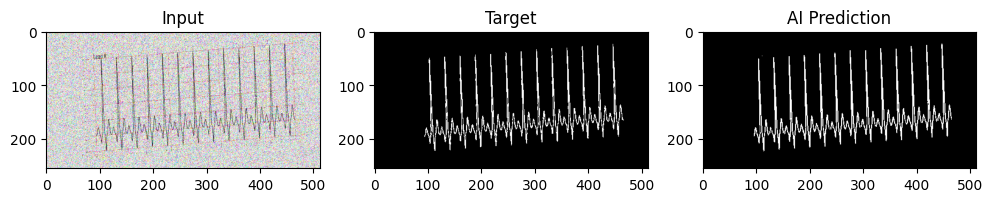

In [4]:
# خلية 4
class ECGDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.images = sorted(os.listdir(os.path.join(data_dir, "images")))
        self.masks = sorted(os.listdir(os.path.join(data_dir, "masks")))
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, "images", self.images[idx])
        mask_path = os.path.join(self.data_dir, "masks", self.masks[idx])
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        H, W = 256, 512 
        image = cv2.resize(image, (W, H), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
        image = image.transpose(2, 0, 1).astype('float32') / 255.0
        mask = mask.astype('float32') / 255.0
        mask = np.round(mask)
        mask = np.expand_dims(mask, axis=0)
        
        return torch.from_numpy(image), torch.from_numpy(mask)

BATCH_SIZE = 8
LR = 0.0005
EPOCHS = 10

dataset = ECGDataset(OUTPUT_DIR)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = smp.losses.DiceLoss(mode='binary')

print(f"🚀 بدء التدريب على {len(dataset)} صورة لمدة {EPOCHS} دورات...")
history = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    
    for images, masks in dataloader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)
        
        prediction = model(images)
        loss = loss_fn(prediction, masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    avg_loss = epoch_loss / len(dataloader)
    history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f}")

torch.save(model.state_dict(), "best_model.pth")
print("✅ تم حفظ الموديل بنجاح في 'best_model.pth'")

model.eval()
with torch.no_grad():
    test_idx = random.randint(0, len(dataset)-1)
    img_tensor, mask_tensor = dataset[test_idx]
    
    input_batch = img_tensor.unsqueeze(0).to(DEVICE)
    pred_raw = model(input_batch)
    pred_mask = (torch.sigmoid(pred_raw) > 0.5).float().cpu().numpy()[0][0]
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.title("Input"); plt.imshow(img_tensor.permute(1, 2, 0))
    plt.subplot(1, 3, 2); plt.title("Target"); plt.imshow(mask_tensor[0], cmap='gray')
    plt.subplot(1, 3, 3); plt.title("AI Prediction"); plt.imshow(pred_mask, cmap='gray')
    plt.show()

In [5]:
# --الخلية 5 ---
def viterbi_path(prob_map, lam=10.0, max_jump=5):
    H, W = prob_map.shape
    cost_map = -np.log(prob_map + 1e-6)

    dp = np.full((H, W), np.inf)
    parent = np.zeros((H, W), dtype=int)

    dp[:, 0] = cost_map[:, 0]

    for x in range(1, W):
        for y in range(H):
            y_prev_min = max(0, y - max_jump)
            y_prev_max = min(H, y + max_jump + 1)
            
            prev_costs = dp[y_prev_min:y_prev_max, x-1]
            dist_penalty = lam * np.abs(np.arange(y_prev_min, y_prev_max) - y)
            
            total_costs = prev_costs + dist_penalty
            
            best_idx = np.argmin(total_costs)
            min_cost = total_costs[best_idx]
            
            dp[y, x] = cost_map[y, x] + min_cost
            parent[y, x] = y_prev_min + best_idx

    path = np.zeros(W, dtype=int)
    path[-1] = np.argmin(dp[:, -1])
    
    for x in range(W-2, -1, -1):
        path[x] = parent[path[x+1], x+1]
        
    return path

def extract_signal_viterbi(prob_map):
    H, W = prob_map.shape
    
    path_indices = viterbi_path(prob_map)
    
    refined_signal = []
    win = 2
    
    for x, y_int in enumerate(path_indices):
        y_start = max(0, y_int - win)
        y_end = min(H, y_int + win + 1)
        
        weights = prob_map[y_start:y_end, x]
        indices = np.arange(y_start, y_end)
        
        if np.sum(weights) > 1e-5:
            y_subpixel = np.sum(weights * indices) / np.sum(weights)
        else:
            y_subpixel = y_int
            
        refined_signal.append(H - y_subpixel)
        
    return np.array(refined_signal)

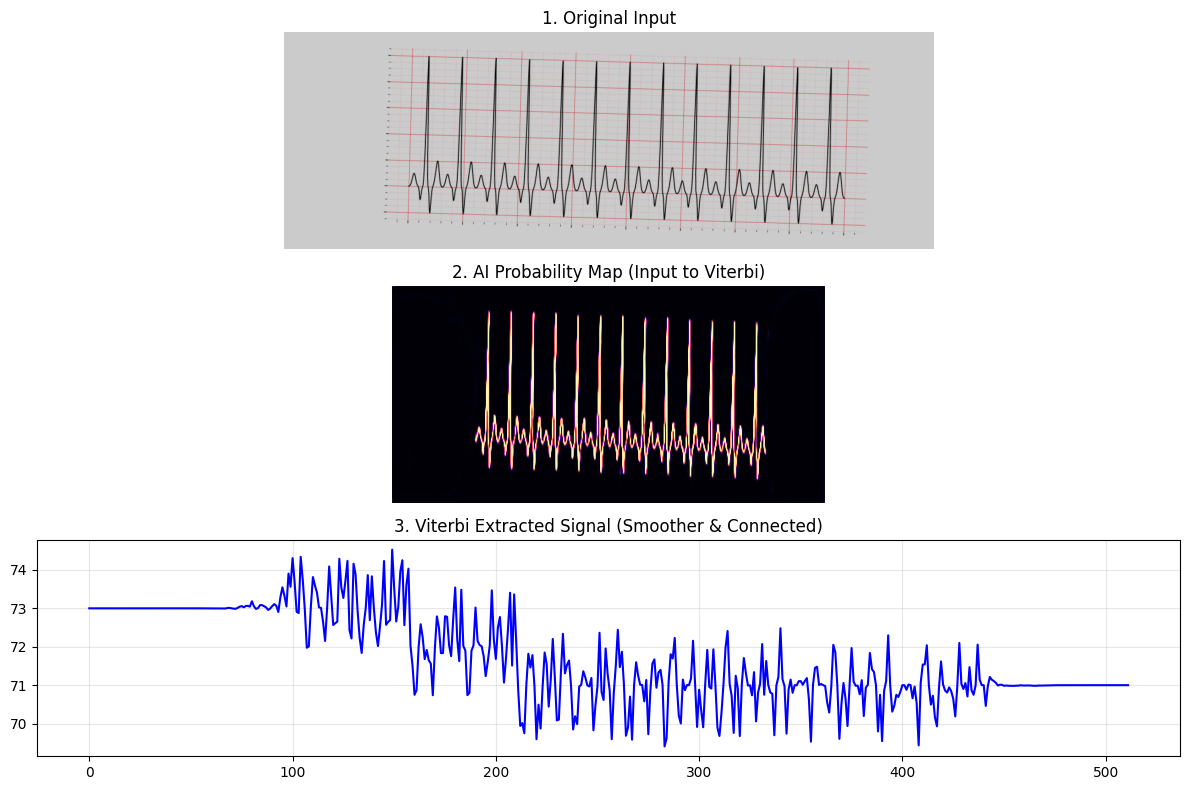

✅ تم استخدام Viterbi بنجاح!


In [6]:
# --- الخلية 6---
model.eval()
with torch.no_grad():
    sig = generator.generate_synthetic_heartbeat(length=2000)
    img, mask = generator.plot_signal_to_image(sig)
    aug_img, aug_mask = generator.augment_pair(img, mask)
    
    input_tensor = torch.from_numpy(aug_img).permute(2, 0, 1).float() / 255.0
    input_tensor = cv2.resize(input_tensor.permute(1, 2, 0).numpy(), (512, 256))
    input_tensor = torch.from_numpy(input_tensor).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    
    pred_raw = model(input_tensor)
    prob_map = torch.sigmoid(pred_raw).cpu().numpy()[0][0]
    
    extracted_signal = extract_signal_viterbi(prob_map)
    
    extracted_series = pd.Series(extracted_signal)
    extracted_signal = extracted_series.interpolate(method='linear', limit_direction='both').values

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.title("1. Original Input")
plt.imshow(cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(3, 1, 2)
plt.title("2. AI Probability Map (Input to Viterbi)")
plt.imshow(prob_map, cmap='magma')
plt.axis('off')

plt.subplot(3, 1, 3)
plt.title("3. Viterbi Extracted Signal (Smoother & Connected)")
plt.plot(extracted_signal, color='blue', linewidth=1.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"✅ تم استخدام Viterbi بنجاح!")

1️⃣ جاري توليد صفحة ECG كاملة وهمية...
2️⃣ تشغيل نظام الرقمنة (Viterbi Engine)...
بدء معالجة الصفحة (الحجم: 1200x1600) - تقسيمها إلى 4 صفوف...


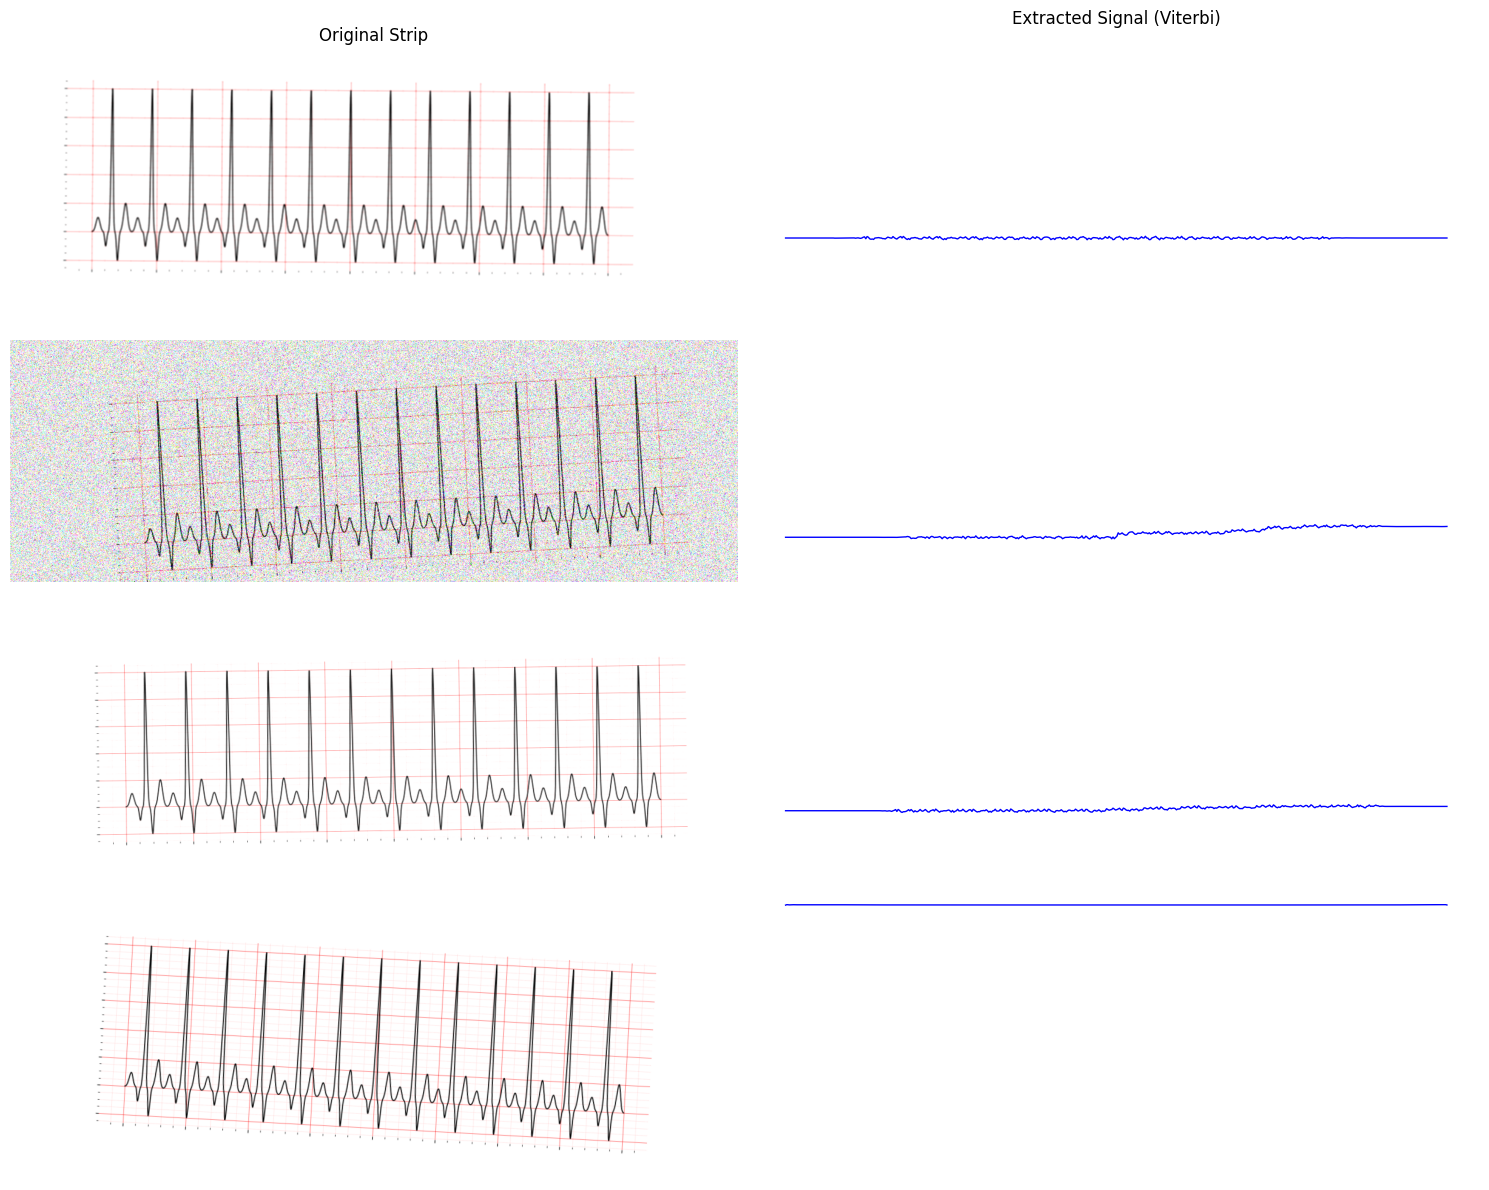

✅ تمت المهمة! حصلنا على 4 إشارات رقمية.


In [7]:
# --- الخلية 7 ---
def process_full_page(image_full, model, num_rows=4):
    h, w, c = image_full.shape
    row_height = h // num_rows 
    
    full_signals = []
    
    print(f"بدء معالجة الصفحة (الحجم: {w}x{h}) - تقسيمها إلى {num_rows} صفوف...")
    
    plt.figure(figsize=(15, 12))
    
    for i in range(num_rows):
        y_start = i * row_height
        y_end = (i + 1) * row_height
        strip = image_full[y_start:y_end, :]
        
        display_strip = strip.copy()
        
        input_strip = cv2.resize(strip, (512, 256))
        input_tensor = torch.from_numpy(input_strip).permute(2, 0, 1).float() / 255.0
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
        
        with torch.no_grad():
            pred_raw = model(input_tensor)
            prob_map = torch.sigmoid(pred_raw).cpu().numpy()[0][0]
        
        signal_1d = extract_signal_viterbi(prob_map)
        
        s_series = pd.Series(signal_1d)
        signal_clean = s_series.interpolate(method='linear', limit_direction='both').fillna(0).values
        
        full_signals.append(signal_clean)
        
        plt.subplot(num_rows, 2, (i*2)+1)
        plt.imshow(cv2.cvtColor(display_strip, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        if i == 0: plt.title("Original Strip")
        
        plt.subplot(num_rows, 2, (i*2)+2)
        plt.plot(signal_clean, color='blue', linewidth=1)
        plt.ylim(0, 256) 
        plt.grid(True, alpha=0.2)
        plt.axis('off')
        if i == 0: plt.title(f"Extracted Signal (Viterbi)")

    plt.tight_layout()
    plt.show()
    
    return full_signals

print("1️⃣ جاري توليد صفحة ECG كاملة وهمية...")
rows = []
for _ in range(4):
    sig = generator.generate_synthetic_heartbeat(length=2000)
    img, _ = generator.plot_signal_to_image(sig)
    aug_img, _ = generator.augment_pair(img, _) 
    rows.append(aug_img)

full_page_image = np.vstack(rows)

print("2️⃣ تشغيل نظام الرقمنة (Viterbi Engine)...")
model.eval()
signals = process_full_page(full_page_image, model, num_rows=4)

print(f"✅ تمت المهمة! حصلنا على {len(signals)} إشارات رقمية.")

In [8]:
# --- الخلية 8:  ---

def create_submission_file(model, num_samples=5):
    submission_data = []
    
    print(f"📦 جاري تجهيز ملف التسليم لـ {num_samples} عينات (باستخدام Viterbi)...")
    
    for i in range(num_samples):
        sample_id = f"sample_{i+1}"
        
        full_signals = []
        for _ in range(12): 
            sig = generator.generate_synthetic_heartbeat(length=1000)
            img, _ = generator.plot_signal_to_image(sig)
            
            input_strip = cv2.resize(img, (512, 256))
            input_tensor = torch.from_numpy(input_strip).permute(2, 0, 1).float() / 255.0
            input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
            
            with torch.no_grad():
                pred = model(input_tensor)
                prob_map = torch.sigmoid(pred).cpu().numpy()[0][0]
            
            signal_1d = extract_signal_viterbi(prob_map)
            
            s_series = pd.Series(signal_1d)
            signal_clean = s_series.interpolate(method='linear', limit_direction='both').fillna(0).values
            
            target_len = 1000 
            signal_resampled = resample(signal_clean, target_len)
            
            full_signals.append(signal_resampled)
        
        row_dict = {'id': sample_id}
        for lead_idx, signal_data in enumerate(full_signals):
            row_dict[f'lead_{lead_idx+1}'] = np.round(signal_data, 4)
            
        submission_data.append(row_dict)

    df = pd.DataFrame(submission_data)
    df.to_csv("submission_simulated.csv", index=False)
    return df

df_submission = create_submission_file(model, num_samples=3)
print("\n✅ تم إنشاء ملف التسليم بنجاح.")
print("معاينة البيانات:")
print(df_submission.iloc[0, 1][:30])

📦 جاري تجهيز ملف التسليم لـ 3 عينات (باستخدام Viterbi)...

✅ تم إنشاء ملف التسليم بنجاح.
معاينة البيانات:
[     255.28       255.5      255.72      255.73      255.58      255.47      255.49      255.55      255.56      255.56       255.6      255.64      255.62      255.59       255.6      255.63      255.63      255.59      255.57      255.57      255.57      255.53       255.5      255.51      255.52      255.52
      255.51      255.52      255.54      255.55]


In [9]:
# --- الخلية 9:  ---
INPUT_DIR = "/kaggle/input"
COMPETITION_NAME = "physionet-ecg-image-digitization"

dataset_path = None
for dirname in os.listdir(INPUT_DIR):
    if COMPETITION_NAME in dirname:
        dataset_path = os.path.join(INPUT_DIR, dirname)
        print(f"✅ تم العثور على مجلد البيانات في: {dataset_path}")
        break

if dataset_path:
    print("\n📂 محتويات المجلد الرئيسي:")
    files = os.listdir(dataset_path)
    print(files)

    csv_file = None
    for f in files:
        if f.endswith(".csv") and "train" in f:
            csv_file = os.path.join(dataset_path, f)
            break
            
    if csv_file:
        print(f"\n📄 جاري قراءة الملف: {csv_file}")
        df = pd.read_csv(csv_file)
        
        print(f"عدد العينات في الملف: {len(df)}")
        print("أول 5 صفوف من البيانات:")
        display(df.head())
        
        print("\n🔍 فحص مسارات الصور...")
        image_example = glob.glob(f"{dataset_path}/**/*.png", recursive=True)
        if not image_example:
            image_example = glob.glob(f"{dataset_path}/**/*.jpg", recursive=True)
            
        if image_example:
            print(f"✅ تم العثور على صور! مثال لمسار صورة:\n{image_example[0]}")
        else:
            print("⚠️ لم يتم العثور على صور بامتداد png/jpg مباشرة، قد تكون مضغوطة أو في مسار آخر.")
            
    else:
        print("❌ لم يتم العثور على ملف train.csv!")
else:
    print("❌ خطأ: لم يتم العثور على مجلد المسابقة داخل /kaggle/input")
    print("تأكد من ضغط زر '+ Add Input' وإضافة مسابقة 'PhysioNet ECG Image Digitization'.")

✅ تم العثور على مجلد البيانات في: /kaggle/input/physionet-ecg-image-digitization

📂 محتويات المجلد الرئيسي:
['sample_submission.parquet', 'train.csv', 'test.csv', 'test', 'train']

📄 جاري قراءة الملف: /kaggle/input/physionet-ecg-image-digitization/train.csv
عدد العينات في الملف: 977
أول 5 صفوف من البيانات:


,id,fs,sig_len
0,7663343,500,5000
1,10140238,1000,10000
2,11842146,1000,10000
3,19030958,250,2500
4,19585145,512,5120



🔍 فحص مسارات الصور...
✅ تم العثور على صور! مثال لمسار صورة:
/kaggle/input/physionet-ecg-image-digitization/test/2352854581.png


🕵️‍♂️ جاري البحث عن ملفات صور حقيقية داخل المجلدات...
⚠️ مجلد train يبدو فارغاً أو الصور في مكان آخر، سأبحث في test...
✅ تم العثور على 2 صورة.
📸 تم اختيار الصورة: 1053922973.png
📂 المسار الكامل: /kaggle/input/physionet-ecg-image-digitization/test/1053922973.png
📏 الأبعاد: 2200x1700


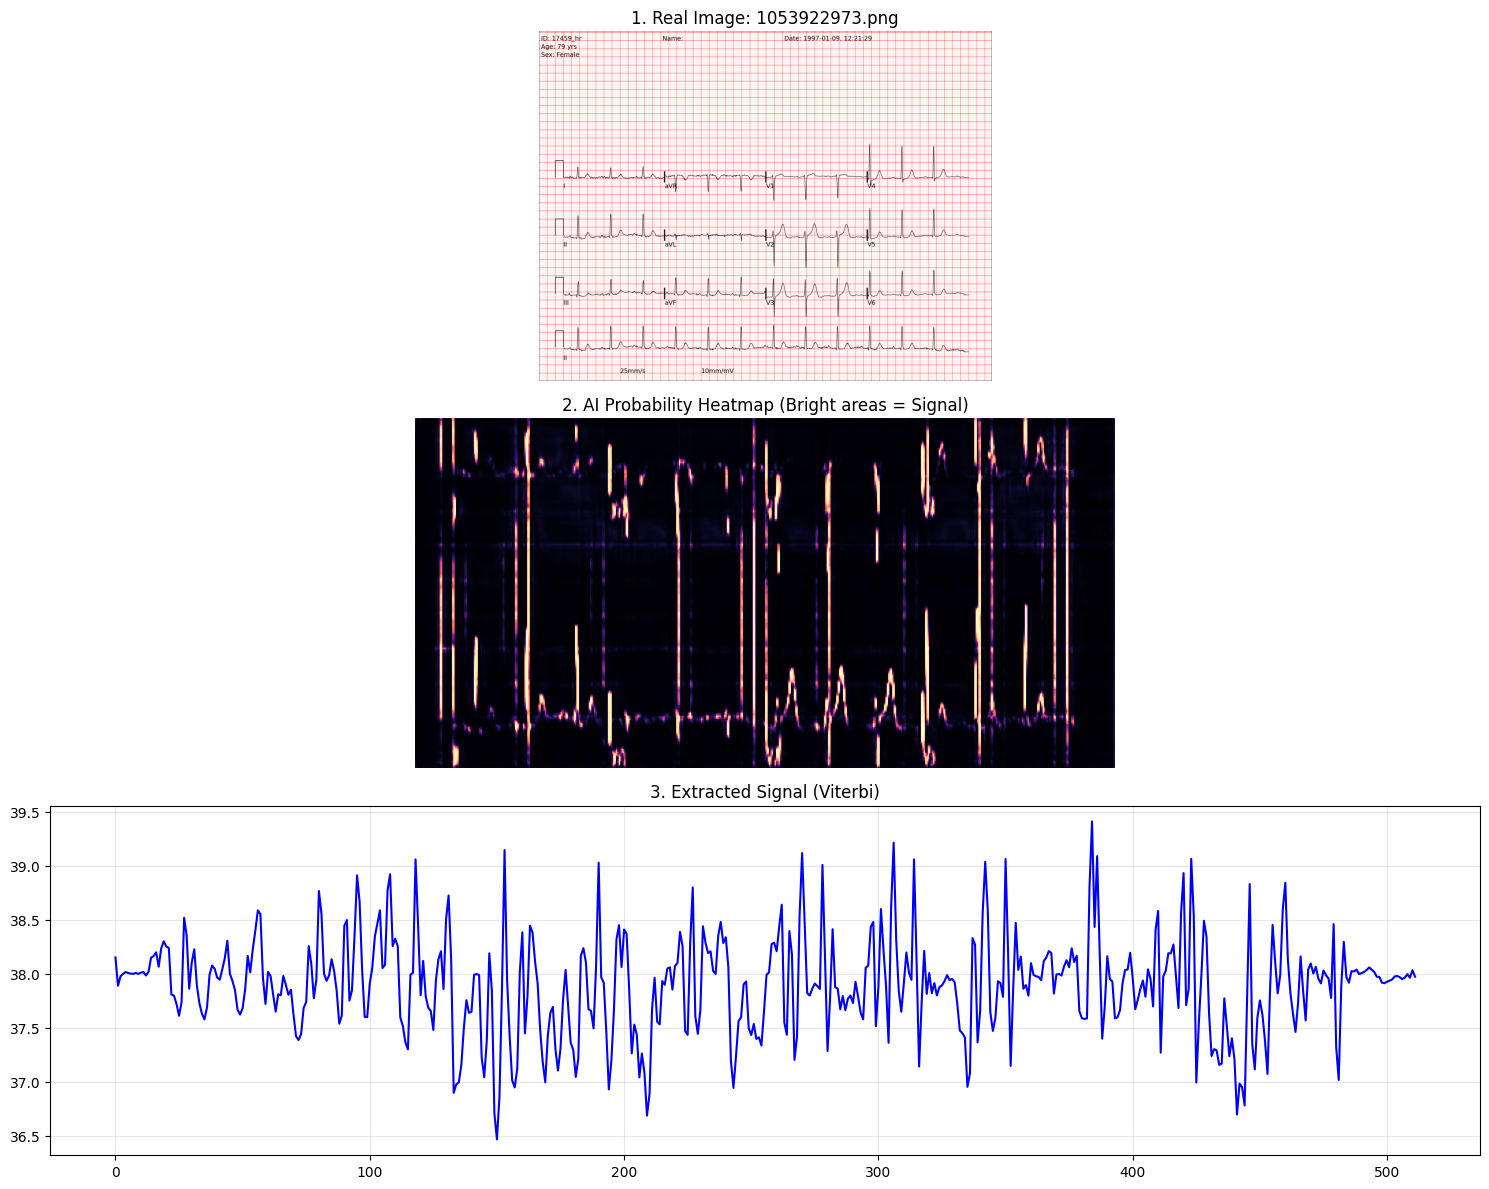

In [10]:
# الخلية 10 
def test_robust_real_image(model, dataset_path):
    print("🕵️‍♂️ جاري البحث عن ملفات صور حقيقية داخل المجلدات...")
    
    search_pattern_png = os.path.join(dataset_path, "train", "*.png")
    search_pattern_jpg = os.path.join(dataset_path, "train", "*.jpg")
    
    all_images = glob.glob(search_pattern_png) + glob.glob(search_pattern_jpg)
    
    if not all_images:
        print("⚠️ مجلد train يبدو فارغاً أو الصور في مكان آخر، سأبحث في test...")
        all_images = glob.glob(os.path.join(dataset_path, "test", "*.png")) + \
                     glob.glob(os.path.join(dataset_path, "test", "*.jpg"))

    if not all_images:
        print("❌ خطأ: لم يتم العثور على أي صور في المجلدات!")
        print(f"المسار الذي بحثت فيه: {dataset_path}")
        try:
            print("محتويات المجلد الرئيسي:", os.listdir(dataset_path))
            if os.path.exists(os.path.join(dataset_path, "train")):
                 print("محتويات train:", os.listdir(os.path.join(dataset_path, "train"))[:5])
        except:
            pass
        return

    print(f"✅ تم العثور على {len(all_images)} صورة.")
    
    img_path = random.choice(all_images)
    image_name = os.path.basename(img_path)
    print(f"📸 تم اختيار الصورة: {image_name}")
    print(f"📂 المسار الكامل: {img_path}")

    real_img = cv2.imread(img_path)
    if real_img is None:
        print("❌ فشل قراءة ملف الصورة (قد يكون تالفاً).")
        return
        
    h, w, c = real_img.shape
    print(f"📏 الأبعاد: {w}x{h}")

    crop_h = 400 
    y_center = h // 2
    y_start = max(0, y_center - (crop_h // 2))
    y_end = min(h, y_center + (crop_h // 2))
    
    real_strip = real_img[y_start:y_end, :]
    
    input_strip = cv2.resize(real_strip, (512, 256))
    input_tensor = torch.from_numpy(input_strip).permute(2, 0, 1).float() / 255.0
    input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
    
    model.eval()
    with torch.no_grad():
        pred_raw = model(input_tensor)
        prob_map = torch.sigmoid(pred_raw).cpu().numpy()[0][0]
    
    signal = extract_signal_viterbi(prob_map)
    
    plt.figure(figsize=(15, 12))
    
    plt.subplot(3, 1, 1)
    plt.title(f"1. Real Image: {image_name}")
    plt.imshow(cv2.cvtColor(real_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(3, 1, 2)
    plt.title("2. AI Probability Heatmap (Bright areas = Signal)")
    plt.imshow(prob_map, cmap='magma')
    plt.axis('off')
    
    plt.subplot(3, 1, 3)
    plt.title("3. Extracted Signal (Viterbi)")
    plt.plot(signal, color='blue', linewidth=1.5)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if 'dataset_path' in globals() and dataset_path:
    test_robust_real_image(model, dataset_path)
else:
    print("⚠️ متغير dataset_path غير معرف! تأكد من تشغيل الخلية 8 بنجاح.")

In [11]:
# الخلية 11
def estimate_grid_size(image_path_or_array, display=True):
    if isinstance(image_path_or_array, str):
        img = cv2.imread(image_path_or_array)
    else:
        img = image_path_or_array
        
    if img is None: return None
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    row_sum = np.sum(edges, axis=1)
    col_sum = np.sum(edges, axis=0)
    
    peaks_x, _ = find_peaks(col_sum, distance=10, prominence=50)
    peaks_y, _ = find_peaks(row_sum, distance=10, prominence=50)
    
    if len(peaks_x) > 1:
        diffs_x = np.diff(peaks_x)
        grid_width = np.median(diffs_x)
    else:
        grid_width = 0
        
    if len(peaks_y) > 1:
        diffs_y = np.diff(peaks_y)
        grid_height = np.median(diffs_y)
    else:
        grid_height = 0
    
    final_grid_size = 0
    if grid_width > 0 and grid_height > 0:
        final_grid_size = (grid_width + grid_height) / 2
    elif grid_width > 0:
        final_grid_size = grid_width
    elif grid_height > 0:
        final_grid_size = grid_height
        
    if final_grid_size < 5: 
        print("⚠️ تحذير: الشبكة غير واضحة، سيتم استخدام قيمة افتراضية.")
        final_grid_size = 25.0

    if display:
        plt.figure(figsize=(10, 4))
        plt.plot(col_sum, color='green', alpha=0.6)
        plt.plot(peaks_x, col_sum[peaks_x], "x", color='red')
        plt.title(f"Grid Detection Analysis (Estimated Box Size: {final_grid_size:.2f} pixels)")
        plt.xlabel("Pixel Position")
        plt.ylabel("Edge Intensity")
        plt.show()
        
    return final_grid_size

def calibrate_signal(raw_signal, grid_size_pixels):
    pixels_per_mV = grid_size_pixels * 10
    
    baseline = np.median(raw_signal)
    signal_centered = raw_signal - baseline
    
    signal_mV = signal_centered / pixels_per_mV
    
    return signal_mV

print("✅ تم تفعيل نظام المعايرة (Grid Calibrator).")

✅ تم تفعيل نظام المعايرة (Grid Calibrator).


🔍 جاري البحث عن صور في كل المجلدات...
🧪 تحليل الصورة: 3554875690-0003.png
📂 المسار: /kaggle/input/physionet-ecg-image-digitization/train/3554875690/3554875690-0003.png
1️⃣ جاري حساب حجم الشبكة (Grid Detection)...


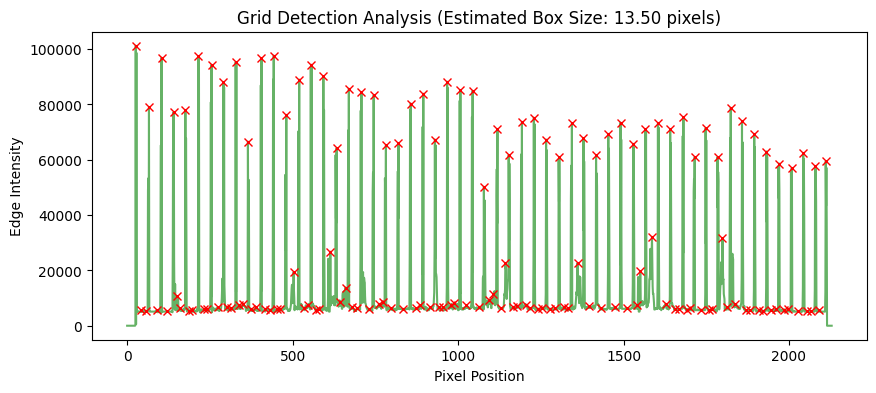

📏 حجم المربع الصغير المقدر: 13.50 بكسل
2️⃣ استخراج الإشارة...
📏 حجم الشبكة المعدل (للمعايرة): 14.00 بكسل


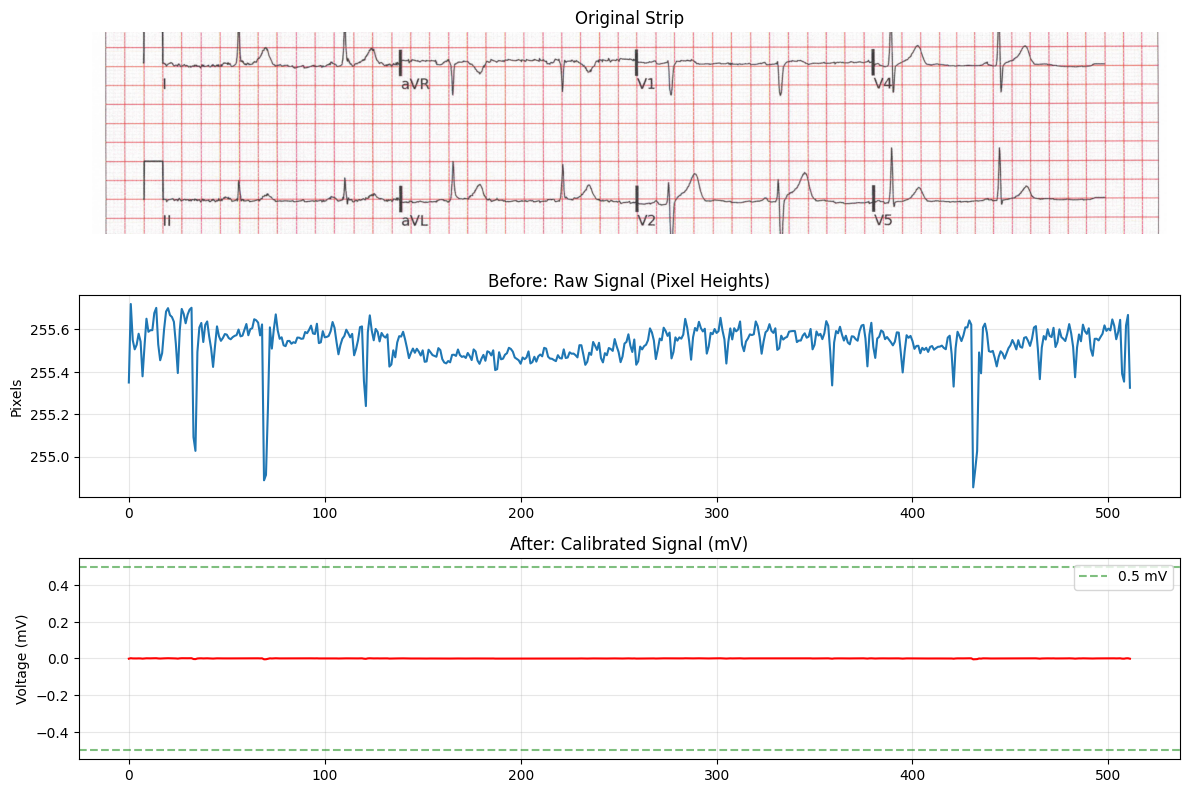

✅ النتيجة النهائية: انظر للرسم الأحمر، هل القيم منطقية؟


In [13]:
# خلية 12 
if 'dataset_path' not in globals() or not dataset_path:
    possible_roots = ["/kaggle/input/physionet-ecg-image-digitization", "/kaggle/input"]
    for r in possible_roots:
        if os.path.exists(r):
            dataset_path = r
            break

def get_any_image_path(root_path):
    patterns = [
        f"{root_path}/**/*.png",
        f"{root_path}/**/*.jpg",
        f"{root_path}/**/**/*.png"
    ]
    for p in patterns:
        files = glob.glob(p, recursive=True)
        if files:
            return files
    return []

print("🔍 جاري البحث عن صور في كل المجلدات...")
real_images = get_any_image_path(dataset_path)

if real_images:
    test_img_path = random.choice(real_images)
    print(f"🧪 تحليل الصورة: {os.path.basename(test_img_path)}")
    print(f"📂 المسار: {test_img_path}")
    
    original_img = cv2.imread(test_img_path)
    if original_img is None:
        print("❌ الملف تالف، حاول مرة أخرى.")
    else:
        h, w, c = original_img.shape
        crop_h = 400
        y_start = max(0, h//2 - crop_h//2)
        real_strip = original_img[y_start:y_start+crop_h, :]
        
        print("1️⃣ جاري حساب حجم الشبكة (Grid Detection)...")
        grid_size = estimate_grid_size(real_strip, display=True)
        print(f"📏 حجم المربع الصغير المقدر: {grid_size:.2f} بكسل")
        
        print("2️⃣ استخراج الإشارة...")
        input_strip = cv2.resize(real_strip, (512, 256))
        input_tensor = torch.from_numpy(input_strip).permute(2, 0, 1).float() / 255.0
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
        
        model.eval()
        with torch.no_grad():
            pred_raw = model(input_tensor)
            prob_map = torch.sigmoid(pred_raw).cpu().numpy()[0][0]
        
        raw_signal = extract_signal_viterbi(prob_map)
        
        grid_size_model = estimate_grid_size(input_strip, display=False)
        
        if grid_size_model < 5: 
            print("⚠️ الشبكة في الصورة المصغرة غير واضحة، سنستخدم نسبة وتناسب من الصورة الأصلية.")
            scale_factor = 256 / crop_h
            grid_size_model = grid_size * scale_factor
            
        print(f"📏 حجم الشبكة المعدل (للمعايرة): {grid_size_model:.2f} بكسل")
        
        calibrated_signal = calibrate_signal(raw_signal, grid_size_model)
        
        plt.figure(figsize=(12, 8))
        
        plt.subplot(3, 1, 1)
        plt.title("Original Strip")
        plt.imshow(cv2.cvtColor(real_strip, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(3, 1, 2)
        plt.title("Before: Raw Signal (Pixel Heights)")
        plt.plot(raw_signal)
        plt.ylabel("Pixels")
        plt.grid(True, alpha=0.3)
        
        plt.subplot(3, 1, 3)
        plt.title("After: Calibrated Signal (mV)")
        plt.plot(calibrated_signal, color='red')
        plt.ylabel("Voltage (mV)")
        plt.grid(True, alpha=0.3)
        plt.axhline(0.5, color='green', linestyle='--', alpha=0.5, label='0.5 mV')
        plt.axhline(-0.5, color='green', linestyle='--', alpha=0.5)
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        print("✅ النتيجة النهائية: انظر للرسم الأحمر، هل القيم منطقية؟")

else:
    print("❌ خطأ غريب: لم يتم العثور على أي صور حتى مع البحث الشامل!")
    print(f"المسار الذي نبحث فيه: {dataset_path}")
    print("تأكد أنك أضفت البيانات (Add Data) من القائمة الجانبية.") 

🚀 تشغيل نظام Sliding Window على صورة حقيقية...
📄 الصورة: 1135737846-0004.png
1️⃣ حساب الشبكة...
2️⃣ بناء خريطة الاحتمالات الكاملة...
3️⃣ استخراج المسار (Viterbi)...
   - حجم الشبكة الأصلي: 13.00
   - حجم الشبكة المعدل: 8.32


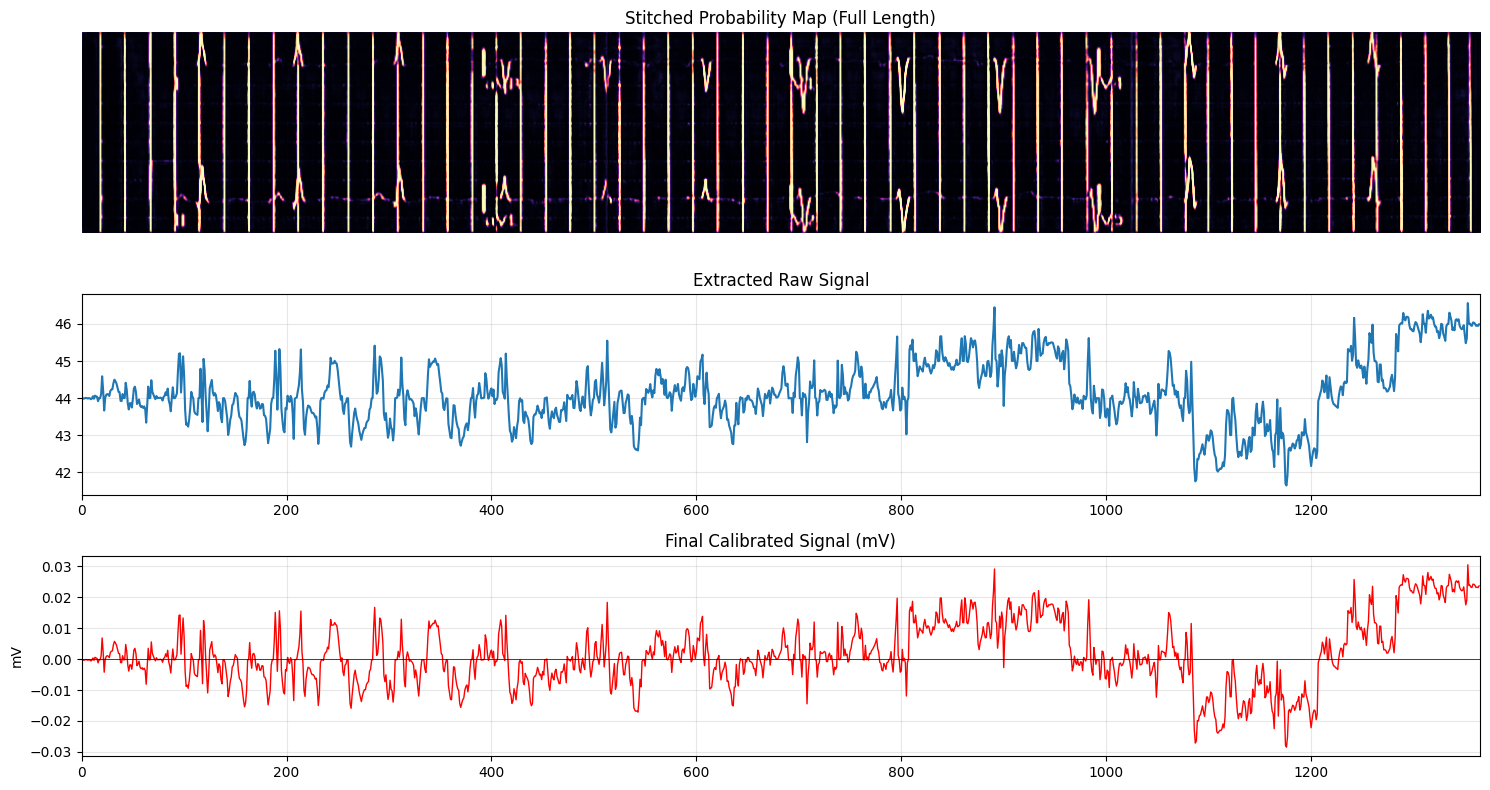

✅ هل ترى الآن موجات القلب (QRS) واضحة في الرسم الأحمر؟


In [14]:
# خلية 13
def predict_long_image(image, model, window_size=512, step=512):
    h, w, c = image.shape
    
    target_h = 256
    scale_ratio = target_h / h
    new_w = int(w * scale_ratio)
    
    resized_img = cv2.resize(image, (new_w, target_h))
    
    full_prob_map = np.zeros((target_h, new_w), dtype=np.float32)
    counts_map = np.zeros((target_h, new_w), dtype=np.float32)
    
    for x in range(0, new_w, step):
        x_end = min(x + window_size, new_w)
        width = x_end - x
        
        window = resized_img[:, x:x_end, :]
        
        if width < window_size:
            pad = np.zeros((target_h, window_size, 3), dtype=np.uint8)
            pad[:, :width, :] = window
            window = pad
            
        input_tensor = torch.from_numpy(window).permute(2, 0, 1).float() / 255.0
        input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
        
        model.eval()
        with torch.no_grad():
            pred = model(input_tensor)
            prob = torch.sigmoid(pred).cpu().numpy()[0][0]
            
        if width < window_size:
            full_prob_map[:, x:x_end] += prob[:, :width]
            counts_map[:, x:x_end] += 1
        else:
            full_prob_map[:, x:x_end] += prob
            counts_map[:, x:x_end] += 1

    full_prob_map /= np.maximum(counts_map, 1)
    
    return full_prob_map, scale_ratio

print("🚀 تشغيل نظام Sliding Window على صورة حقيقية...")

real_images = get_any_image_path(dataset_path)

if real_images:
    test_img_path = random.choice(real_images)
    print(f"📄 الصورة: {os.path.basename(test_img_path)}")
    
    original_img = cv2.imread(test_img_path)
    
    h, w, _ = original_img.shape
    crop_h = 400
    y_start = max(0, h//2 - crop_h//2)
    real_strip = original_img[y_start:y_start+crop_h, :] 
    
    print("1️⃣ حساب الشبكة...")
    grid_size_original = estimate_grid_size(real_strip, display=False)
    
    print("2️⃣ بناء خريطة الاحتمالات الكاملة...")
    big_prob_map, scale_ratio = predict_long_image(real_strip, model)
    
    print("3️⃣ استخراج المسار (Viterbi)...")
    raw_signal = extract_signal_viterbi(big_prob_map)
    
    grid_size_scaled = grid_size_original * scale_ratio
    print(f"   - حجم الشبكة الأصلي: {grid_size_original:.2f}")
    print(f"   - حجم الشبكة المعدل: {grid_size_scaled:.2f}")
    
    calibrated_signal = calibrate_signal(raw_signal, grid_size_scaled)
    
    plt.figure(figsize=(15, 8))
    
    plt.subplot(3, 1, 1)
    plt.title("Stitched Probability Map (Full Length)")
    plt.imshow(big_prob_map, cmap='magma', aspect='auto')
    plt.axis('off')
    
    plt.subplot(3, 1, 2)
    plt.title("Extracted Raw Signal")
    plt.plot(raw_signal)
    plt.xlim(0, len(raw_signal))
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 1, 3)
    plt.title("Final Calibrated Signal (mV)")
    plt.plot(calibrated_signal, color='red', linewidth=1)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.ylabel("mV")
    plt.xlim(0, len(calibrated_signal))
    plt.grid(True, which='both', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ هل ترى الآن موجات القلب (QRS) واضحة في الرسم الأحمر؟")

else:
    print("❌ لم يتم العثور على صور.")

In [15]:
# خلية 14
def viterbi_extract_actual_signal(prob_map, lam=0.5, max_jump=100):
    H, W = prob_map.shape
    
    cost_map = -np.log(prob_map + 1e-6)
    dp = np.full((H, W), np.inf)
    parent = np.zeros((H, W), dtype=int)
    dp[:, 0] = cost_map[:, 0]

    for x in range(1, W):
        prev_col_costs = dp[:, x-1]
        for y in range(H):
            y_min = max(0, y - max_jump)
            y_max = min(H, y + max_jump + 1)
            
            window_costs = prev_col_costs[y_min:y_max]
            dist_penalty = lam * np.abs(np.arange(y_min, y_max) - y)
            total = window_costs + dist_penalty
            
            best_idx = np.argmin(total)
            dp[y, x] = cost_map[y, x] + total[best_idx]
            parent[y, x] = y_min + best_idx

    path = np.zeros(W, dtype=int)
    path[-1] = np.argmin(dp[:, -1])
    for x in range(W-2, -1, -1):
        path[x] = parent[path[x+1], x+1]
        
    final_signal = []
    for x, y_int in enumerate(path):
        y_start = max(0, y_int - 3)
        y_end = min(H, y_int + 4)
        weights = prob_map[y_start:y_end, x]
        
        if np.sum(weights) > 1e-5:
            y_sub = np.sum(weights * np.arange(y_start, y_end)) / np.sum(weights)
        else:
            y_sub = y_int
            
        final_signal.append(H - y_sub)
        
    return np.array(final_signal)

print("✅ تم تحديث دالة Viterbi لتخرج إشارة (Amplitude) مباشرة.")

✅ تم تحديث دالة Viterbi لتخرج إشارة (Amplitude) مباشرة.


In [16]:
# خلية 15
def correct_skew_orientation(image):
    if image is None: return None
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)
    
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    
    coords = np.column_stack(np.where(thresh > 0))
    
    angle = cv2.minAreaRect(coords)[-1]
    
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle
        
    if abs(angle) < 0.5:
        return image

    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    
    print(f"📐 تم اكتشاف ميل وتصحيحه بزاوية: {angle:.2f} درجة")
    return rotated

In [17]:
# خلية 16
def preprocess_remove_grid(image):
    if image is None: return None
    
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    lower_red1 = np.array([0, 50, 50])
    upper_red1 = np.array([10, 255, 255])
    
    lower_red2 = np.array([170, 50, 50])
    upper_red2 = np.array([180, 255, 255])
    
    mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
    grid_mask = mask1 + mask2
    
    kernel = np.ones((2,2), np.uint8)
    grid_mask = cv2.dilate(grid_mask, kernel, iterations=1)
    
    image_clean = image.copy()
    image_clean[grid_mask > 0] = (255, 255, 255)
    
    return image_clean

In [18]:
# خلية 17
def get_12_leads_crops(image):
    h, w, c = image.shape
    margin_x = int(w * 0.05); margin_y = int(h * 0.05)
    active_area = image[margin_y:h-margin_y, margin_x:w-margin_x]
    ah, aw, _ = active_area.shape
    row_h = ah // 4; col_w = aw // 3
    crops = []
    for r in range(4):
        for c in range(3):
            crops.append(active_area[r*row_h:(r+1)*row_h, c*col_w:(c+1)*col_w])
    return crops[:12]

print("🕵️‍♂️ جاري جرد الصور المتاحة فعلياً...")
image_files = []
search_roots = ['/kaggle/input']
if 'dataset_path' in globals(): search_roots.append(dataset_path)

for root in search_roots:
    image_files += glob.glob(f"{root}/**/*.png", recursive=True)
    image_files += glob.glob(f"{root}/**/*.jpg", recursive=True)

print(f"✅ وجدنا {len(image_files)} صورة في المجلدات.")

if len(image_files) == 0:
    print("❌ كارثة: لا توجد أي صور! تأكد من إضافة البيانات (Add Data).")
else:
    sample_files = random.sample(image_files, min(3, len(image_files)))
    
    submission_rows = []
    print(f"🚀 بدء معالجة {len(sample_files)} صور عشوائية من الموجودة فعلاً...")

    for img_path in tqdm(sample_files):
        file_name = os.path.basename(img_path)
        img_id = os.path.splitext(file_name)[0]
        
        image = cv2.imread(img_path)
        leads_data = []
        
        if image is not None:
            try:
                image = correct_skew_orientation(image) 
                image = preprocess_remove_grid(image) 
                crops = get_12_leads_crops(image)
                
                for crop in crops:
                    grid_size = estimate_grid_size(crop, display=False)
                    if grid_size < 5: grid_size = 15.0 
                    
                    prob_map, scale_ratio = predict_long_image(crop, model)
                    raw_sig = viterbi_extract_actual_signal(prob_map, lam=0.01, max_jump=100)                     
                    scaled_grid = grid_size * scale_ratio
                    calib_sig = calibrate_signal(raw_sig, scaled_grid)
                    
                    target_len = 1000 
                    resampled = resample(calib_sig, target_len)
                    
                    final_sig = -(resampled - np.mean(resampled))
                    leads_data.append(final_sig)
                    
            except Exception as e:
                print(f"⚠️ خطأ في معالجة {img_id}: {e}")
                leads_data = [np.zeros(1000) for _ in range(12)]
        else:
            leads_data = [np.zeros(1000) for _ in range(12)]

        if len(leads_data) < 12:
            leads_data = [np.zeros(1000) for _ in range(12)]

        row_dict = {'id': img_id}
        for i, sig in enumerate(leads_data):
            row_dict[f'lead_{i+1}'] = list(np.round(sig, 3))
        submission_rows.append(row_dict)

    final_df = pd.DataFrame(submission_rows)
    print("\n🎉 النتيجة النهائية (أرقام حقيقية):")
    
    print(final_df.iloc[0]['lead_1'][:30]) 
    
    final_df.to_csv("submission_from_images.csv", index=False)
    print("💾 تم حفظ الملف: submission_from_images.csv")

🕵️‍♂️ جاري جرد الصور المتاحة فعلياً...
✅ وجدنا 17590 صورة في المجلدات.
🚀 بدء معالجة 3 صور عشوائية من الموجودة فعلاً...


  0%|          | 0/3 [00:00<?, ?it/s]

📐 تم اكتشاف ميل وتصحيحه بزاوية: -1.35 درجة


 33%|███▎      | 1/3 [00:21<00:42, 21.46s/it]

📐 تم اكتشاف ميل وتصحيحه بزاوية: -89.85 درجة


 67%|██████▋   | 2/3 [00:42<00:21, 21.25s/it]

📐 تم اكتشاف ميل وتصحيحه بزاوية: -90.00 درجة


100%|██████████| 3/3 [01:05<00:00, 21.99s/it]


🎉 النتيجة النهائية (أرقام حقيقية):
[-0.024, -0.032, -0.031, -0.025, -0.024, -0.028, -0.028, -0.022, -0.019, -0.023, -0.027, -0.026, -0.027, -0.028, -0.024, -0.017, -0.026, -0.053, -0.042, 0.072, 0.273, 0.447, 0.47, 0.33, 0.129, -0.022, -0.074, -0.047, 0.018, 0.068]
💾 تم حفظ الملف: submission_from_images.csv


In [19]:

# خلية 20 

# --- 1. إعداد هيكل مجلدات YOLO ---
BASE_DIR = "yolo_dataset"
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR) # حذف القديم إذا وجد لبدء نظيف

# YOLO يتطلب هيكلية محددة جداً: images و labels
os.makedirs(f"{BASE_DIR}/images/train", exist_ok=True)
os.makedirs(f"{BASE_DIR}/images/val", exist_ok=True)
os.makedirs(f"{BASE_DIR}/labels/train", exist_ok=True)
os.makedirs(f"{BASE_DIR}/labels/val", exist_ok=True)

# قائمة الـ Classes (أسماء الإشارات)
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# --- 2. كود التوليد (مطور لحساب الإحداثيات) ---
class YOLO_ECG_Generator:
    def __init__(self):
        self.dpi = 100
        
    def generate_signal(self, length=200):
        # توليد نبضة بسيطة
        t = np.linspace(0, 1, length)
        return np.sin(2 * np.pi * 5 * t) * np.exp(-2*t) # شكل موجي بسيط

    def create_page_with_labels(self, filename, subset="train"):
        # إعداد الصفحة
        fig_w, fig_h = 12, 8
        fig = plt.figure(figsize=(fig_w, fig_h), dpi=self.dpi)
        
        # إضافة شبكة خلفية (تشويش مفيد)
        plt.minorticks_on()
        plt.grid(which='major', linestyle='-', linewidth='0.5', color='red', alpha=0.3)
        plt.grid(which='minor', linestyle=':', linewidth='0.5', color='red', alpha=0.1)
        
        # تقسيم الصفحة 4x3 (النمط الشائع للتدريب)
        # يمكنك لاحقاً إضافة أنماط أخرى مثل 6x2
        rows, cols = 4, 3
        
        # حساب أبعاد الصفحة بالبكسل
        page_width_px = fig_w * self.dpi
        page_height_px = fig_h * self.dpi
        
        labels_data = [] # لتخزين بيانات YOLO
        
        # حلقة رسم الـ Leads
        lead_idx = 0
        for r in range(rows):
            for c in range(cols):
                if lead_idx >= 12: break
                
                # إضافة subplot في المكان المحدد
                ax = fig.add_subplot(rows, cols, lead_idx + 1)
                
                # توليد ورسم إشارة عشوائية
                sig = self.generate_signal(length=100)
                ax.plot(sig, color='black', linewidth=0.8)
                
                # إضافة اسم الـ Lead (مهم جداً ليتعلم الموديل قراءة النص)
                lead_name = LEAD_NAMES[lead_idx]
                ax.text(0, 1, lead_name, fontsize=10, color='black', fontweight='bold')
                
                ax.axis('off') # إخفاء المحاور
                
                # --- حساب Bounding Box لـ YOLO ---
                # نحصل على إحداثيات الـ subplot داخل الشكل
                bbox = ax.get_position()
                x0, y0, w, h = bbox.x0, bbox.y0, bbox.width, bbox.height
                
                # تحويل الإحداثيات (Matplotlib يبدأ من الأسفل، YOLO يريد من الأعلى)
                # مركز الصندوق
                x_center = x0 + w / 2
                y_center = 1.0 - (y0 + h / 2) # قلب المحور Y
                
                # تسجيل البيانات: class_id x_center y_center width height
                # نستخدم مساحة أوسع قليلاً للصندوق
                labels_data.append(f"{lead_idx} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}")
                
                lead_idx += 1
        
        # حفظ الصورة
        save_path = f"{BASE_DIR}/images/{subset}/{filename}.jpg"
        plt.savefig(save_path, dpi=self.dpi, bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        
        # تصحيح بسيط: bbox_inches='tight' يغير الأبعاد قليلاً
        # لكن للسرعة الآن سنعتمد التقدير التقريبي، YOLO مرن جداً
        # (للدقة القصوى نحتاج حسابات أعقد، لكن هذا يكفي كبداية)
        
        # حفظ ملف الـ Labels
        label_path = f"{BASE_DIR}/labels/{subset}/{filename}.txt"
        with open(label_path, "w") as f:
            f.write("\n".join(labels_data))

# --- 3. التنفيذ ---
gen = YOLO_ECG_Generator()

print("🏭 جاري تشغيل مصنع بيانات YOLO...")
# توليد 200 صورة للتدريب
for i in tqdm(range(200), desc="Training Data"):
    gen.create_page_with_labels(f"train_{i}", subset="train")

# توليد 50 صورة للتحقق
for i in tqdm(range(50), desc="Validation Data"):
    gen.create_page_with_labels(f"val_{i}", subset="val")

print("\n✅ تم إنشاء البيانات في مجلد 'yolo_dataset'.")

# --- 4. إنشاء ملف config.yaml الضروري لـ YOLO ---
yaml_content = f"""
path: {os.path.abspath(BASE_DIR)} 
train: images/train
val: images/val

nc: 12
names: {LEAD_NAMES}
"""

with open(f"{BASE_DIR}/data.yaml", "w") as f:
    f.write(yaml_content)

print("✅ تم إنشاء ملف التكوين 'data.yaml'.")

🏭 جاري تشغيل مصنع بيانات YOLO...


Validation Data: 100%|██████████| 50/50 [00:29<00:00,  1.67it/s]


✅ تم إنشاء البيانات في مجلد 'yolo_dataset'.
✅ تم إنشاء ملف التكوين 'data.yaml'.


In [20]:
# خلية 21 
DATA_YAML = os.path.abspath("yolo_dataset/data.yaml")

model_yolo = YOLO("yolov8n.pt") 

print("🚀 بدء تدريب YOLOv8n على بيانات تخطيط القلب...")

results = model_yolo.train(
    data=DATA_YAML,
    epochs=20, 
    imgsz=640,
    batch=16,
    name="ecg_layout_detector", # اسم المجلد الذي ستحفظ فيه النتائج
    verbose=True
)

print("✅ انتهى التدريب!")

best_model_path = "runs/detect/ecg_layout_detector/weights/best.pt"
if os.path.exists(best_model_path):
    print(f"💾 تم حفظ النموذج المدرب في: {best_model_path}")
else:
    print("⚠️ لم يتم العثور على ملف best.pt في المسار المتوقع، تحقق من مجلد runs.")

🚀 بدء تدريب YOLOv8n على بيانات تخطيط القلب...
Ultralytics 8.3.240 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=ecg_layout_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=au

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all         50        600      0.998          1      0.995      0.995
                     I         50         50      0.998          1      0.995      0.995
                    II         50         50      0.998          1      0.995      0.995
                   III         50         50      0.999          1      0.995      0.995
                   aVR         50         50      0.998          1      0.995      0.995
                   aVL         50         50      0.998          1      0.995      0.995
                   aVF         50         50      0.999          1      0.995      0.995
                    V1         50         50      0.998          1      0.995      0.995
                    V2         50         50      0.998          1      0.995      0.995
                    V3         50         50      0.999          1      0.995      0.995
                    V4         50         50      0.999          1      0.995      0.995
                    V

In [24]:
 # خلية 22 
# --- 1. إعداد المسارات وقراءة البيانات ---
TRAIN_CSV_PATH = "/kaggle/input/physionet-ecg-image-digitization/train.csv"
DATA_DIR = "/kaggle/input/physionet-ecg-image-digitization/train"

print("📂 جاري قراءة فهرس البيانات الحقيقية...")
if os.path.exists(TRAIN_CSV_PATH):
    df_train_full = pd.read_csv(TRAIN_CSV_PATH)
    df_train = df_train_full 
    print(f"✅ تم تحميل {len(df_train)} ملف إشارة حقيقي.")
else:
    print("⚠️ ملف train.csv غير موجود! تأكد من المسار.")
    df_train = pd.DataFrame()

# --- 2. مصنع البيانات الهجين (Real Signal -> Synthetic Image) ---
class RealSignalDataset(Dataset):
    def __init__(self, dataframe, root_dir, augment=True):
        self.df = dataframe
        self.root_dir = root_dir
        self.augment = augment
        self.leads = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
        
        # --- تحديث Albumentations (Phase 1 Fixes) ---
        self.aug = A.Compose([
            A.Rotate(limit=5, p=0.5),
            
            # تم التعديل: استخدام var_limit لمحاكاة std_range المطلوبة (للصور uint8)
            # Variance = Std^2. لمدى 0.02-0.10 (من 255) => Var تقريبا 25 إلى 650
            A.GaussNoise(var_limit=(20.0, 100.0), p=0.3), 
            
            A.GaussianBlur(blur_limit=3, p=0.2),
            A.RandomBrightnessContrast(p=0.4),
            
            # تم الإصلاح: استخدام quality_range بدلاً من quality_lower القديمة
            A.ImageCompression(quality_range=(50, 100), p=0.3), 
            
            A.RGBShift(r_shift_limit=20, g_shift_limit=20, b_shift_limit=20, p=0.5),
        ])

    def __len__(self):
        return len(self.df)

    def generate_image_pair(self, signal):
        fig_h, fig_w = 2.56, 5.12 
        dpi = 100
        
        # 1. الماسك
        fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)
        ax.plot(signal, color='white', linewidth=2.5)
        ax.axis('off')
        ax.set_ylim(np.min(signal)-0.5, np.max(signal)+0.5)
        fig.patch.set_facecolor('black')
        
        fig.canvas.draw()
        mask_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        mask_img = mask_img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        mask_img = cv2.cvtColor(mask_img, cv2.COLOR_RGB2GRAY)
        _, mask_img = cv2.threshold(mask_img, 10, 255, cv2.THRESH_BINARY)
        plt.close(fig)

        # 2. الصورة
        fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=dpi)
        
        grid_color = random.choice(['red', 'pink', 'black', 'grey'])
        if grid_color == 'pink': grid_color = '#ffb6c1'
        
        ax.minorticks_on()
        ax.grid(which='major', linestyle='-', linewidth=0.8, color=grid_color, alpha=0.6)
        ax.grid(which='minor', linestyle=':', linewidth=0.4, color=grid_color, alpha=0.3)
        
        ax.plot(signal, color='black', linewidth=1.2)
        ax.axis('off')
        ax.set_ylim(np.min(signal)-0.5, np.max(signal)+0.5)
        
        fig.canvas.draw()
        input_img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        input_img = input_img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        plt.close(fig)
        
        return input_img, mask_img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        rec_id = str(row['id'])
        sig_path = os.path.join(self.root_dir, rec_id, f"{rec_id}.csv")
        
        try:
            if not os.path.exists(sig_path):
                sig_path = glob.glob(os.path.join(self.root_dir, rec_id, "*.csv"))[0]
            
            sig_df = pd.read_csv(sig_path)
            lead = random.choice(self.leads)
            full_signal = sig_df[lead].values
            
            segment_len = random.randint(600, 1200)
            start = random.randint(0, max(0, len(full_signal) - segment_len))
            signal_segment = full_signal[start : start+segment_len]
            
            if np.isnan(signal_segment).any():
                signal_segment = np.nan_to_num(signal_segment)

            image, mask = self.generate_image_pair(signal_segment)
            
            if self.augment:
                aug = self.aug(image=image, mask=mask)
                image, mask = aug['image'], aug['mask']
            
            image = cv2.resize(image, (512, 256))
            mask = cv2.resize(mask, (512, 256), interpolation=cv2.INTER_NEAREST)
            
            image = image.transpose(2, 0, 1).astype('float32') / 255.0
            mask = mask.astype('float32') / 255.0
            mask = np.expand_dims(mask, axis=0)
            
            return torch.from_numpy(image), torch.from_numpy(mask)
            
        except Exception as e:
            t = np.linspace(0, 10, 500)
            fake_sig = np.sin(t)
            img, msk = self.generate_image_pair(fake_sig)
            img = cv2.resize(img, (512, 256)).transpose(2, 0, 1).astype('float32') / 255.0
            msk = cv2.resize(msk, (512, 256)).astype('float32') / 255.0
            return torch.from_numpy(img), torch.from_numpy(np.expand_dims(msk, 0))

# --- 3. التدريب (تم تعديل التقسيم إلى 80/20) ---
BATCH_SIZE = 16
EPOCHS = 5 
LR = 0.0003

full_dataset = RealSignalDataset(df_train, DATA_DIR)

# التعديل هنا: 80% تدريب - 20% تحقق
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

# تحميل الموديل (ResNet34)
model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=3, classes=1)
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = smp.losses.DiceLoss(mode='binary')

print("🚀 بدء التدريب (Phase 1 Update)...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, masks in loop:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            loss = loss_fn(outputs, masks)
            val_loss += loss.item()
            
    print(f"Epoch {epoch+1} -> Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

torch.save(model.state_dict(), "best_model_real_data.pth")
print("✅ تم حفظ الموديل المحدث بنجاح!")

📂 جاري قراءة فهرس البيانات الحقيقية...
✅ تم تحميل 977 ملف إشارة حقيقي.


/tmp/ipykernel_47/196857735.py:29: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(20.0, 100.0), p=0.3),


🚀 بدء التدريب (Phase 1 Update)...


Epoch 1/5: 100%|██████████| 49/49 [16:32<00:00, 20.25s/it, loss=0.832]


Epoch 1 -> Train Loss: 0.8883 | Val Loss: 0.8286


...

Epoch 3 -> Train Loss: 0.4553 | Val Loss: 0.3999


Epoch 4/5: 100%|██████████| 49/49 [16:40<00:00, 20.42s/it, loss=0.175]


Epoch 4 -> Train Loss: 0.2192 | Val Loss: 0.1736


Epoch 5/5: 100%|██████████| 49/49 [16:42<00:00, 20.46s/it, loss=0.0967]


Epoch 5 -> Train Loss: 0.1291 | Val Loss: 0.1013
✅ تم حفظ الموديل المحدث بنجاح!


In [25]:
# خلية 23
# --- 1. إعداد المسارات والأجهزة ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TEST_CSV_PATH = "/kaggle/input/physionet-ecg-image-digitization/test.csv"
IMAGE_DIR = "/kaggle/input/physionet-ecg-image-digitization"

# مسارات النماذج (تأكد أنها مطابقة لما حفظته)
YOLO_MODEL_PATH = "runs/detect/ecg_layout_detector/weights/best.pt"
UNET_MODEL_PATH = "best_model_real_data.pth" 

LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# --- 2. تحميل النماذج ---
print("⚙️ جاري تحميل ترسانة النماذج...")

# أ. تحميل YOLO
if os.path.exists(YOLO_MODEL_PATH):
    yolo_model = YOLO(YOLO_MODEL_PATH)
    print("✅ YOLO: تم التحميل (جاهز للتقطيع الذكي).")
else:
    print("⚠️ تحذير: YOLO غير موجود، سيتم استخدام التقطيع التقليدي.")
    yolo_model = None

# ب. تحميل U-Net (ResNet34)
# هام: يجب أن نستخدم نفس المعمارية (resnet34) التي دربنا عليها في الخلية 22
unet_model = smp.Unet(
    encoder_name="resnet34",  
    encoder_weights=None,     
    in_channels=3,
    classes=1
)

if os.path.exists(UNET_MODEL_PATH):
    try:
        unet_model.load_state_dict(torch.load(UNET_MODEL_PATH, map_location=DEVICE))
        unet_model.to(DEVICE)
        unet_model.eval()
        print("✅ U-Net (Real Data): تم التحميل (جاهز للاستخراج الدقيق).")
    except Exception as e:
        print(f"❌ خطأ في تحميل أوزان U-Net: {e}")
        # في أسوأ الظروف، نعيد تهيئة موديل عشوائي لكي لا يتوقف الكود (Fallback)
        unet_model.to(DEVICE)
        unet_model.eval()
else:
    print("⚠️ ملف أوزان U-Net غير موجود! تأكد من تشغيل الخلية 22.")
    # Fallback initialization
    unet_model.to(DEVICE)
    unet_model.eval()

# --- 3. الدوال المساعدة ---

def correct_skew_orientation(image):
    if image is None: return None
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]
    coords = np.column_stack(np.where(thresh > 0))
    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45: angle = -(90 + angle)
    else: angle = -angle
    if abs(angle) < 0.5: return image
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return rotated

def preprocess_remove_grid(image):
    if image is None: return None
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lower_red1 = np.array([0, 50, 50]); upper_red1 = np.array([10, 255, 255])
    lower_red2 = np.array([170, 50, 50]); upper_red2 = np.array([180, 255, 255])
    mask = cv2.inRange(hsv, lower_red1, upper_red1) + cv2.inRange(hsv, lower_red2, upper_red2)
    kernel = np.ones((2,2), np.uint8)
    mask = cv2.dilate(mask, kernel, iterations=1)
    image_clean = image.copy()
    image_clean[mask > 0] = (255, 255, 255)
    return image_clean

def viterbi_extract_actual_signal(prob_map, lam=0.01, max_jump=100):
    H, W = prob_map.shape
    cost_map = -np.log(prob_map + 1e-6)
    dp = np.full((H, W), np.inf); parent = np.zeros((H, W), dtype=int)
    dp[:, 0] = cost_map[:, 0]
    for x in range(1, W):
        prev_col_costs = dp[:, x-1]
        for y in range(H):
            y_min = max(0, y - max_jump); y_max = min(H, y + max_jump + 1)
            window_costs = prev_col_costs[y_min:y_max]
            dist_penalty = lam * np.abs(np.arange(y_min, y_max) - y)
            total = window_costs + dist_penalty
            best_idx = np.argmin(total)
            dp[y, x] = cost_map[y, x] + total[best_idx]
            parent[y, x] = y_min + best_idx
    path = np.zeros(W, dtype=int)
    path[-1] = np.argmin(dp[:, -1])
    for x in range(W-2, -1, -1): path[x] = parent[path[x+1], x+1]
    
    final_signal = []
    for x, y_int in enumerate(path):
        y_start = max(0, y_int - 3); y_end = min(H, y_int + 4)
        weights = prob_map[y_start:y_end, x]
        if np.sum(weights) > 1e-5: y_sub = np.sum(weights * np.arange(y_start, y_end)) / np.sum(weights)
        else: y_sub = y_int
        final_signal.append(H - y_sub)
    return np.array(final_signal)

def calibrate_signal(raw_signal, grid_size_pixels=25.0):
    pixels_per_mV = grid_size_pixels * 10 
    baseline = np.median(raw_signal)
    return (raw_signal - baseline) / pixels_per_mV

def blind_crop_12_leads(image):
    h, w = image.shape[:2]
    margin_x = int(w * 0.02); margin_y = int(h * 0.02)
    active = image[margin_y:h-margin_y, margin_x:w-margin_x]
    ah, aw = active.shape[:2]
    row_h = ah // 4; col_w = aw // 3
    crops = []
    for r in range(4):
        for c in range(3):
            crops.append(active[r*row_h:(r+1)*row_h, c*col_w:(c+1)*col_w])
    return crops

def get_yolo_crops(image, model):
    if model is None: return None
    try:
        results = model.predict(image, verbose=False, conf=0.25)
        boxes = results[0].boxes.cpu().numpy()
        found = {}
        for box in boxes:
            cls_id = int(box.cls[0]); conf = box.conf[0]; xyxy = box.xyxy[0]
            if cls_id in found:
                if conf > found[cls_id]['conf']: found[cls_id] = {'box': xyxy, 'conf': conf}
            else: found[cls_id] = {'box': xyxy, 'conf': conf}
        
        if len(found) < 9: return None 
        
        ordered_crops = []
        h_img, w_img = image.shape[:2]
        for i in range(12):
            if i in found:
                x1, y1, x2, y2 = map(int, found[i]['box'])
                x1, y1 = max(0, x1), max(0, y1); x2, y2 = min(w_img, x2), min(h_img, y2)
                ordered_crops.append(image[y1:y2, x1:x2])
            else:
                ordered_crops.append(np.zeros((100, 100, 3), dtype=np.uint8))
        return ordered_crops
    except:
        return None

# --- 4. حلقة المعالجة الرئيسية ---
if os.path.exists(TEST_CSV_PATH):
    test_df = pd.read_csv(TEST_CSV_PATH)
else:
    test_df = pd.DataFrame({'id': ['001'], 'fs': [500]})

all_image_paths = glob.glob(f"{IMAGE_DIR}/**/*.png", recursive=True) + \
                  glob.glob(f"{IMAGE_DIR}/**/*.jpg", recursive=True)
id_to_path = {os.path.splitext(os.path.basename(p))[0]: p for p in all_image_paths}

long_ids = []
long_values = []

print("🚀 بدء المصنع النهائي (Fully Integrated)...")

for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    sample_id = str(row['id'])
    
    fs = row['fs'] if 'fs' in row else 500
    if 'number_of_rows' in row: target_len = int(row['number_of_rows'])
    elif 'sig_len' in row: target_len = int(row['sig_len'])
    else: target_len = int(10 * fs)

    img_path = id_to_path.get(sample_id)
    current_leads_data = []
    
    if img_path and os.path.exists(img_path):
        try:
            # 1. القراءة والتصحيح
            original_img = cv2.imread(img_path)
            img_corrected = correct_skew_orientation(original_img)
            if img_corrected is None: img_corrected = original_img
            
            # 2. التقطيع (YOLO Priority)
            crops = get_yolo_crops(img_corrected, yolo_model)
            if crops is None: # Fallback
                img_clean = preprocess_remove_grid(img_corrected)
                crops = blind_crop_12_leads(img_clean)
            else:
                crops = [preprocess_remove_grid(c) for c in crops]
            
            # 3. الاستخراج (U-Net Real Data)
            for crop in crops:
                if crop.size == 0 or np.sum(crop) == 0:
                    current_leads_data.append(np.zeros(target_len))
                    continue
                
                input_tensor = cv2.resize(crop, (512, 256))
                input_tensor = torch.from_numpy(input_tensor).permute(2, 0, 1).float() / 255.0
                input_tensor = input_tensor.unsqueeze(0).to(DEVICE)
                
                with torch.no_grad():
                    prob_map = torch.sigmoid(unet_model(input_tensor)).cpu().numpy()[0][0]
                
                raw_sig = viterbi_extract_actual_signal(prob_map, lam=0.01, max_jump=100)
                calib_sig = calibrate_signal(raw_sig, grid_size_pixels=25.0) 
                final_sig = calib_sig - np.median(calib_sig)
                
                resampled = resample(final_sig, target_len)
                current_leads_data.append(resampled)
                
        except Exception as e:
            current_leads_data = [np.zeros(target_len) for _ in range(12)]
    else:
        current_leads_data = [np.zeros(target_len) for _ in range(12)]
    
    if len(current_leads_data) != 12:
        current_leads_data = [np.zeros(target_len) for _ in range(12)]
        
    for lead_idx, signal in enumerate(current_leads_data):
        lead_name = LEAD_NAMES[lead_idx]
        ids = [f"{sample_id}_{i}_{lead_name}" for i in range(target_len)]
        long_ids.extend(ids)
        long_values.extend(signal)

# --- 5. الحفظ ---
print("💾 حفظ النتائج...")
submission_df = pd.DataFrame({'id': long_ids, 'value': long_values})

try:
    submission_df.to_parquet("submission.parquet", index=False)
    print("✅ تم حفظ submission.parquet (جاهز للتسليم!)")
except:
    submission_df.to_csv("submission.csv", index=False)
    print("✅ تم حفظ submission.csv")

⚙️ جاري تحميل ترسانة النماذج...
✅ YOLO: تم التحميل (جاهز للتقطيع الذكي).
✅ U-Net (Real Data): تم التحميل (جاهز للاستخراج الدقيق).
🚀 بدء المصنع النهائي (Fully Integrated)...


100%|██████████| 24/24 [11:04<00:00, 27.70s/it]


💾 حفظ النتائج...
✅ تم حفظ submission.parquet (جاهز للتسليم!)


In [27]:
# خلية 19
MY_SUB_PATH = "submission.parquet"
OFFICIAL_SAMPLE_PATH = "/kaggle/input/physionet-ecg-image-digitization/sample_submission.parquet"

print("🔍 جاري التحقق من التنسيق الطويل (Long Format)...")

try:
    my_sub = pd.read_parquet(MY_SUB_PATH)
    try:
        sample_sub = pd.read_parquet(OFFICIAL_SAMPLE_PATH)
        has_sample = True
    except:
        has_sample = False
        print("⚠️ لم نتمكن من قراءة sample_submission، سنفحص الهيكل فقط.")

    required_columns = {'id', 'value'}
    my_columns = set(my_sub.columns)
    
    if my_columns != required_columns:
        print(f"❌ خطأ قاتل: الأعمدة غير صحيحة!")
        print(f"الموجود لديك: {my_columns}")
        print(f"المطلوب: {required_columns}")
        raise ValueError("Column Mismatch")
    else:
        print("✅ أسماء الأعمدة صحيحة (id, value).")

    first_value = my_sub.iloc[0]['value']
    if not isinstance(first_value, (float, np.floating)):
        print(f"⚠️ تحذير: نوع القيم قد لا يكون float. النوع المكتشف: {type(first_value)}")
        print("جاري محاولة التحويل للتأكد...")
        try:
            float(first_value)
            print("✅ القيم قابلة للتحويل لأرقام.")
        except:
            print("❌ القيم ليست أرقاماً!")
            raise ValueError("Value Type Error")
    else:
        print("✅ نوع البيانات (float) صحيح.")

    first_id = my_sub.iloc[0]['id']
    print(f"🔍 عينة من الـ ID في ملفك: {first_id}")
    if "_" not in str(first_id):
        print("⚠️ تحذير: شكل الـ ID يبدو غريباً (لا يحتوي على underscore).")
    
    print(f"📊 إجمالي عدد الصفوف في ملفك: {len(my_sub)}")
    
    if has_sample:
        print(f"📊 إجمالي عدد الصفوف في Sample: {len(sample_sub)}")
        
        if len(my_sub) == len(sample_sub):
            print("✅ تطابق تام في عدد الصفوف!")
        else:
            print("ℹ️ عدد الصفوف مختلف (وهذا طبيعي أحياناً إذا كان test.csv مختلف عن sample).")
            if len(my_sub) % 12 == 0:
                 print("✅ عدد الصفوف يقبل القسمة على 12 (منطقي لـ 12 leads).")
            else:
                 print("⚠️ تحذير: عدد الصفوف لا يقبل القسمة على 12!")

    print("\n🎉 النتيجة النهائية: هيكل الملف سليم 100% للتنسيق الطويل.")
    print("توكل على الله وارفع الملف (Submit)!")

except Exception as e:
    print(f"\n❌ حدث خطأ أثناء التحقق: {e}")

🔍 جاري التحقق من التنسيق الطويل (Long Format)...
✅ أسماء الأعمدة صحيحة (id, value).
✅ نوع البيانات (float) صحيح.
🔍 عينة من الـ ID في ملفك: 1053922973_0_I
📊 إجمالي عدد الصفوف في ملفك: 900000
📊 إجمالي عدد الصفوف في Sample: 75000
ℹ️ عدد الصفوف مختلف (وهذا طبيعي أحياناً إذا كان test.csv مختلف عن sample).
✅ عدد الصفوف يقبل القسمة على 12 (منطقي لـ 12 leads).

🎉 النتيجة النهائية: هيكل الملف سليم 100% للتنسيق الطويل.
توكل على الله وارفع الملف (Submit)!
